# Starch content rating of iodine-stained apple cross-sections — Granny (minimal reproduction)

**Paper:** *Rating Pome Fruit Quality Traits Using Deep Learning and Image Processing*, bioRxiv preprint v1, DOI [10.1101/2024.04.03.588000](https://doi.org/10.1101/2024.04.03.588000) (posted 2024-04-05). Tool authors (per the pinned repository): Nhan H. Nguyen, Heidi Hargarten, Loren Honaas, Stephen P. Ficklin.

**Code:** [`SystemsGenetics/granny`](https://github.com/SystemsGenetics/granny) (GPL-3.0), pinned release **v1.1.0**, commit `411a64825292979f3539568832f9a9851cf854b0`.

**Scope — partial demonstration of one module.** This notebook reproduces the paper's **starch content rating subsection**: it runs the author's released `StarchArea` analysis on 18 iodine-stained apple cross-section images (the author demo tray's segmentation outputs shipped in the repository) and reports (a) the starch-area fraction ("rating") and (b) starch-pattern-index (SPI) style ratings for several standard charts. Fruit detection/segmentation, the scald / pear-color / blush modules, and the paper's human-rating validation study are **out of scope**.

**Execution status:** executed top-to-bottom in a fresh Google Colab **CPU** runtime (no GPU needed). All scientific logic is the author's pinned code; the download/display cells are glue written for this notebook and do not alter the computation.

**日本語要約:** このノートブックは、ヨウ素染色したリンゴの断面画像18枚（著者提供のセグメンテーション済みデモ画像）に対して、著者らの公開コード Granny v1.1.0 のデンプン評価モジュール（`StarchArea`）を実行し、デンプン面積率（rating）と各デンプンパターン指数（SPI系）への対応付けを再現します。GPUは不要で、CPUランタイムのみで動作します。検出・セグメンテーションや人手評価との検証は範囲外です。

**Preprint ↔ released-code note.** The preprint describes the starch step as an ImageJ/Fiji macro (color threshold, a division line, Analyze Particles with ROI exclusions). The repository's current release implements the same scientific module in Python/OpenCV; the mapping between the two is shown below the method section, and the notebook cross-checks the module's output against the author's macro-era expected results shipped in the same commit. **AI-assisted note:** the author did not provide this Colab implementation; this notebook only orchestrates the author's own pinned code.

## Runtime selection & how to run

Select **Runtime → Change runtime type → CPU** (the default free runtime). The starch module is pure OpenCV/NumPy per-image processing; a GPU adds nothing. **Run all** takes only a few minutes and downloads ≈12 MB of demo images plus a small `pip` install.

**日本語:** ランタイムはCPUのみで十分です（GPU不要）。「ランタイム → すべてのセルを実行」で数分で完了し、ダウンロードは約12MBです。

## 1. Environment setup

The starch analysis needs only `numpy`, `opencv-python` (`cv2`) and `pandas` — all preinstalled on Colab. We install the **pinned author commit** with `--no-deps` so that the heavy segmentation dependencies (`torch`/`ultralytics`), which the starch module never imports, are not pulled in. We verify the exact import path used (`Granny.Analyses.StarchArea`) afterwards.

**日本語:** デンプン解析に必要なのは numpy / OpenCV / pandas のみ（Colabに同梱済み）。著者コードのピン留めされたコミットを `--no-deps` でインストールします（セグメンテーション用の重い依存 torch/ultralytics は不要なため入れない）。

In [ ]:
import sys, subprocess

REPO_URL = "https://github.com/SystemsGenetics/granny"
COMMIT = "411a64825292979f3539568832f9a9851cf854b0"

# Show the interpreter and key library versions actually used.
print("Python:", sys.version.split()[0])
import numpy, cv2, pandas
print("numpy", numpy.__version__, "| cv2", cv2.__version__, "| pandas", pandas.__version__)

# Install the pinned author release without its segmentation-only dependencies.
r = subprocess.run(
    [sys.executable, "-m", "pip", "install", "--no-deps", "--quiet",
     f"git+{REPO_URL}@{COMMIT}"],
    capture_output=True, text=True,
)
print("pip exit:", r.returncode)
if r.returncode != 0:
    print(r.stdout[-1500:], r.stderr[-1500:])
    raise RuntimeError("Pinned granny install failed")

Python: 3.13.16


numpy 2.1.3 | cv2 5.0.0 | pandas 2.2.3


pip exit: 0


The install is verified by importing the exact analysis class used below and printing its adjustable defaults (the module's documented parameters: `starch_threshold` 0–255, default 172; `blur_kernel` odd, default 7; `mask_alpha` 0–1, default 0.6).

**日本語:** インストール後、実際に使う解析クラスをインポートして既定パラメータ（閾値172、ぼかしカーネル7、マスク透明度0.6）を確認します。

In [ ]:
# Verify the pinned package imports and show the module's adjustable defaults
# (docs/users_guide/adjustable_parameters.rst: starch_threshold=172, blur_kernel=7, mask_alpha=0.6).
from Granny.Analyses.StarchArea import StarchArea
from Granny import __file__ as granny_init
print("Granny package at:", granny_init)
probe = StarchArea()
print("starch_threshold =", probe.starch_threshold.getValue())
print("blur_kernel      =", probe.blur_kernel.getValue())
print("mask_alpha       =", probe.mask_alpha.getValue())

Granny package at: /usr/local/lib/python3.13/dist-packages/Granny/__init__.py
starch_threshold = 172
blur_kernel      = 7
mask_alpha       = 0.6


## 2. Minimal input acquisition with provenance

Inputs are the **author-provided** demo cross-sections at `test-assets/images/starch/` — the segmentation outputs of the demo tray (18 PNGs, ≈11.1 MB). We list them once from the GitHub tree API **at the pinned commit**, then download each file from the pinned raw URL. Integrity is checked against the commit's git blob SHA-1 for every file, plus a PNG signature check. No token or Drive mount is needed.

**日本語:** 入力は著者提供のデモ断面画像18枚です。ピン留めしたコミットのGitHub tree APIで一覧を取得し、同じコミットのraw URLからダウンロードします。各ファイルはgit blob SHA-1とPNGシグネチャで検証します（トークンやDriveは不要）。

In [ ]:
import json, urllib.request

COMMIT = "411a64825292979f3539568832f9a9851cf854b0"
DIR_PREFIX = "test-assets/images/starch/"

api_url = f"https://api.github.com/repos/SystemsGenetics/granny/git/trees/{COMMIT}?recursive=1"
with urllib.request.urlopen(api_url, timeout=60) as resp:
    tree = json.load(resp)
assert not tree.get("truncated"), "tree listing was truncated"

entries = [t for t in tree["tree"]
           if t["path"].startswith(DIR_PREFIX) and t["path"].endswith(".png")]
print("starch demo images found:", len(entries))
print("total bytes:", sum(t["size"] for t in entries))
assert len(entries) == 18, "expected the 18 demo cross-sections"


starch demo images found: 18
total bytes: 11136511


Each file is downloaded once from the pinned raw URL and verified byte-for-byte: PNG magic signature, size equality with the pinned tree entry, and the git blob SHA-1 recomputed from the actual bytes must all match. A sample SHA-256 is printed for the run record.

**日本語:** 各ファイルはraw URLから1回ずつ取得し、PNGシグネチャ・サイズ・git blob SHA-1をコミットのtreeエントリと照合して検証します。

In [ ]:
import hashlib, pathlib, urllib.request

INPUT_DIR = pathlib.Path("/content/granny_starch_demo")
INPUT_DIR.mkdir(exist_ok=True)

def git_blob_sha(data: bytes) -> str:
    # Git object hash of a blob, used to verify bytes against the pinned tree.
    h = hashlib.sha1()
    h.update(f"blob {len(data)}\0".encode())
    h.update(data)
    return h.hexdigest()

for t in entries:
    name = t["path"].split("/")[-1]
    raw = f"https://raw.githubusercontent.com/SystemsGenetics/granny/{COMMIT}/{t['path']}"
    dest = INPUT_DIR / name
    urllib.request.urlretrieve(raw, dest)
    data = dest.read_bytes()
    assert data[:8] == b"\x89PNG\r\n\x1a\n", f"not a PNG: {name}"
    assert len(data) == t["size"], f"size mismatch: {name}"
    assert git_blob_sha(data) == t["sha"], f"blob hash mismatch: {name}"
print("downloaded and verified:", len(list(INPUT_DIR.glob('*.png'))), "PNGs")
print("sample:", "cross_section_demo_image_1.png",
      hashlib.sha256((INPUT_DIR / 'cross_section_demo_image_1.png').read_bytes()).hexdigest())

downloaded and verified: 18 PNGs
sample: cross_section_demo_image_1.png 10aeb2a113d56c4671268417d66d2705bcc0c9296303fd0f683eab93c694cac7


We also download the **author's macro-era expected results** (`demo/cross_section_images/output/Results.csv`, the ImageJ macro's own output for these 18 images, shipped in the same commit). It is used later only as a labelled cross-version comparison — not as ground truth.

**日本語:** 同じコミットに含まれる、かつてのImageJマクロによる期待結果（`Results.csv`）も取得します。後で「実装間の比較」としてのみ使い、正解データとしては扱いません。

In [ ]:
import urllib.request

MACRO_RESULTS = "/content/macro_Results.csv"
url = (f"https://raw.githubusercontent.com/SystemsGenetics/granny/{COMMIT}"
       "/demo/cross_section_images/output/Results.csv")
urllib.request.urlretrieve(url, MACRO_RESULTS)
text = open(MACRO_RESULTS).read()
print("macro Results.csv bytes:", len(text))
print(text[:400])

macro Results.csv bytes: 1823
Cross-Section,Total cross-section area,Starch area #1,Starch area #2,Starch area #3,Starch area #4,Starch area #5,Starch area #6,Starch area #7,Starch area #8,Starch area #9,Starch area #10,Total Starch Area,Percent Starch Area,Cornell Starch Rating,Jonagold Starch Rating,Purdue Starch Rating,UC GrannySmith Starch Rating
cross_section_demo_image_1,257352,240789,0,0,0,0,0,0,0,0,0,240789,93.5641,2,1


## 3. Input preview

The 18 iodine-stained cross-sections (author demo tray, `test-assets/images/starch/`, pinned commit `411a6482`). Dark violet/black regions are starch stained by Lugol's solution. These are the *segmentation outputs* that the released starch module expects as input — exactly how the paper's pipeline feeds the module after its detection/segmentation step (out of scope here).

**日本語:** 入力画像18枚のプレビュー。黒〜紫色の領域がヨウ素で染色されたデンプンです。このノートブックでは既にセグメンテーション済みの著者提供画像を入力とします。

images: 18


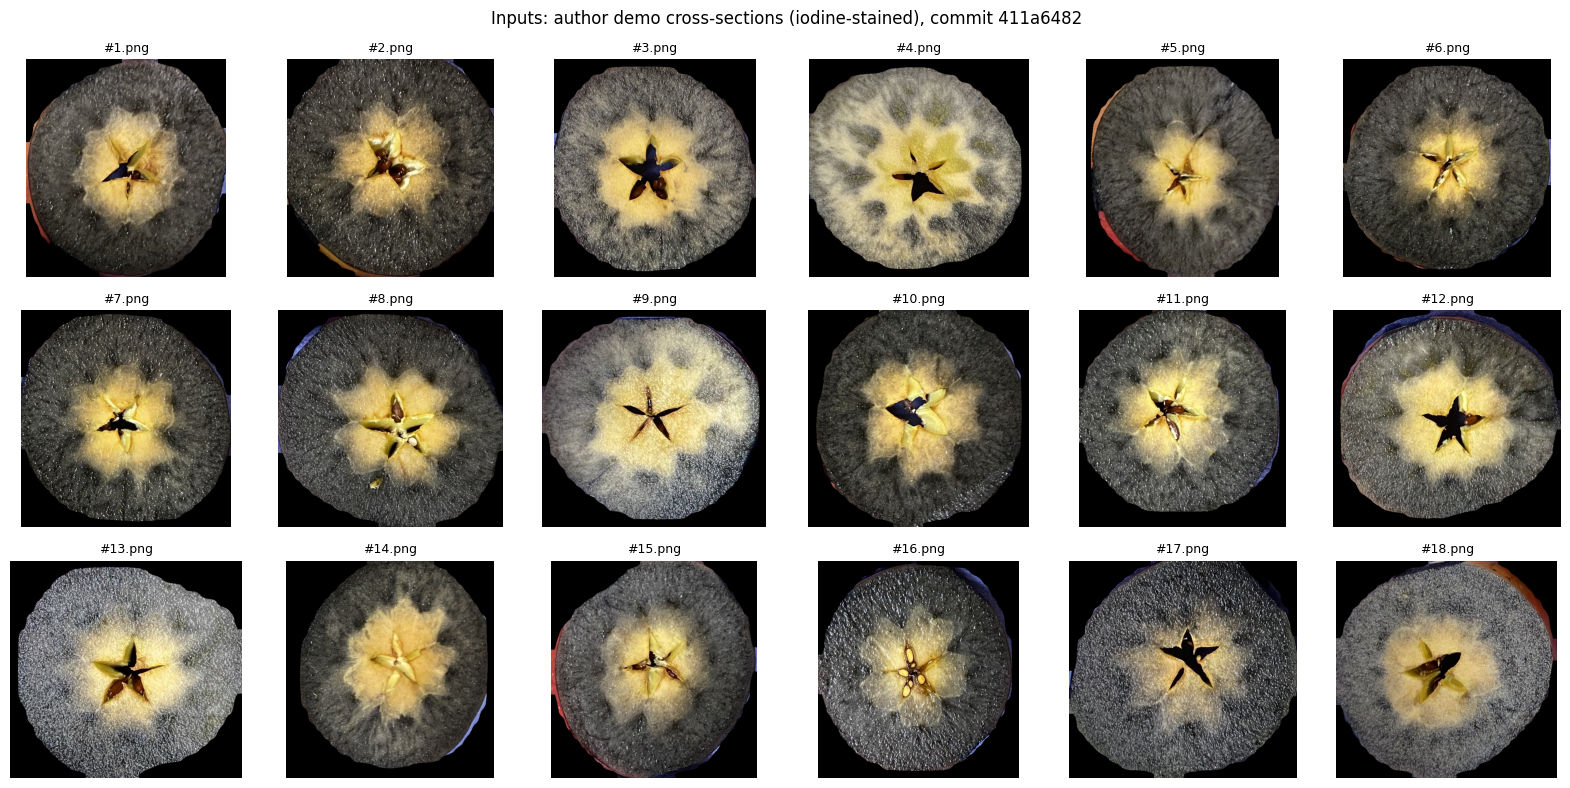

In [ ]:
import cv2
import matplotlib.pyplot as plt

names = sorted(INPUT_DIR.glob("*.png"), key=lambda p: int("".join(filter(str.isdigit, p.name))))
print("images:", len(names))

fig, axes = plt.subplots(3, 6, figsize=(16, 8))
for ax, p in zip(axes.ravel(), names):
    ax.imshow(cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB))
    ax.set_title(p.name.replace("cross_section_demo_image_", "#"), fontsize=9)
    ax.axis("off")
fig.suptitle("Inputs: author demo cross-sections (iodine-stained), commit 411a6482")
fig.tight_layout()
plt.show()

## 4. Method: what the released `StarchArea` module computes

Per image, the pinned module (`Granny/Analyses/StarchArea.py`, v1.1.0) does:

1. Gaussian blur (7×7, `blur_kernel`), then grayscale.
2. Contrast stretch of the gray histogram support to [0, 255].
3. Binary threshold: gray ≤ `starch_threshold` (default 172) ⇒ starch pixels.
4. `rating` = starch pixels / nonzero-gray pixels (the cross-section area).
5. For each bundled chart (`HONEY_CRISP`, `WA38_1`, `WA38_2`, `ALLAN_BROS`, `GOLDEN_DELICIOUS`, `GRANNY_SMITH`, `JONAGOLD`, `CORNELL`): the index whose calibration rating is closest to the computed fraction.

| Paper-era ImageJ macro (`Apple_starch_analysis_macro_3.5.ijm`, commit `b41f915e`) | Released v1.1.0 Python module (pinned commit) |
|---|---|
| 8-bit, Manual Threshold 5–172 (starch) | Gaussian blur 7×7 → gray → stretch to [0,255] → gray ≤ 172 |
| Division line drawn into the image (x=196) | not present (not needed: inputs are clean subimages) |
| Analyze Particles 250–∞; total area 5–255 with particles ≥ 2000 px² | pixel-count ratio over the nonzero-gray support |
| %starch = Σ starch-ROI area / total area × 100 | rating = starch pixels / total pixels (0–1) |
| Quadratic fits → Cornell / Jonagold / Purdue / UC GrannySmith indices | nearest-neighbour lookup → 8 bundled charts |

The scientific operation — *iodine-stained area fraction mapped to SPI-style ratings* — is preserved; implementation details differ, and the notebook labels all cross-implementation comparisons accordingly.

**日本語:** v1.1.0モジュールは「ガウスぼかし→グレースケール→コントラスト伸長→閾値172以下をデンプン」として面積率 rating を求め、各チャートの較正値に最も近い指数を選びます。前処版のImageJマクロ（閾値5–172、分割線、粒子解析）と同じ科学的操作（染色面積率→指数対応付け）をPythonで実装し直したものであり、細部は異なります。比較は「実装間比較」として明示します。

## 5. Run the author's starch analysis on the demo tray

This calls the author's own `StarchArea.performAnalysis()` (the same entry point the CLI uses for `granny -i cli --analysis starch --input …`) with the module defaults. Outputs are written under `/content/results/starch/<timestamp>/`: masked overlay images, `results.csv`, and `tray_summary.csv`.

**日本語:** 著者モジュールの `performAnalysis()` をデフォルト設定で実行します（CLIの `--analysis starch` と同じ経路）。結果は `/content/results/starch/<タイムスタンプ>/` に保存されます。

In [ ]:
import time

analysis = StarchArea()
analysis.input_images.setValue(str(INPUT_DIR))
analysis.addInParam(analysis.input_images)   # required input parameter

t0 = time.time()
results = analysis.performAnalysis()
elapsed = time.time() - t0

OUT_DIR = analysis.output_images.getValue()
print(f"processed {len(results)} images in {elapsed:.1f} s")
print("output directory:", OUT_DIR)
import os
print(sorted(os.listdir(OUT_DIR)))

processed 18 images in 1.3 s
output directory: ./results/starch/2026-10-07-19-18
['cross_section_demo_image_1.png', 'cross_section_demo_image_10.png', 'cross_section_demo_image_11.png', 'cross_section_demo_image_12.png', 'cross_section_demo_image_13.png', 'cross_section_demo_image_14.png', 'cross_section_demo_image_15.png', 'cross_section_demo_image_16.png', 'cross_section_demo_image_17.png', 'cross_section_demo_image_18.png', 'cross_section_demo_image_2.png', 'cross_section_demo_image_3.png', 'cross_section_demo_image_4.png', 'cross_section_demo_image_5.png', 'cross_section_demo_image_6.png', 'cross_section_demo_image_7.png', 'cross_section_demo_image_8.png', 'cross_section_demo_image_9.png', 'results.csv', 'tray_summary.csv']


## 6. Results: ratings and chart indices

`results.csv` has one row per cross-section: the computed starch-area `rating` (0–1) plus the closest index for each bundled starch chart, and `tray_summary.csv` the tray-level means. Values shown are from the actual run above.

**日本語:** `results.csv`（画像ごとの rating と各チャート指数）と `tray_summary.csv`（トレー平均）を表示します。

In [ ]:
import pandas as pd

df = pd.read_csv(os.path.join(OUT_DIR, "results.csv"))
print("results.csv:", df.shape)
df

results.csv: (18, 11)


,Name,HONEY_CRISP,WA38_1,WA38_2,ALLAN_BROS,GOLDEN_DELICIOUS,GRANNY_SMITH,JONAGOLD,CORNELL,rating,TrayName
0,cross_section_demo_image_1.png,2.0,2.0,2.0,3.0,2.0,1.0,2.0,3.0,0.861608,cross_section_demo_image
1,cross_section_demo_image_10.png,2.0,2.0,2.0,3.0,2.0,1.0,2.0,2.0,0.870632,cross_section_demo_image
2,cross_section_demo_image_11.png,2.0,2.0,2.0,3.0,2.0,2.0,2.0,3.0,0.841590,cross_section_demo_image
3,cross_section_demo_image_12.png,3.0,3.0,3.0,4.0,2.5,2.0,3.0,3.0,0.794240,cross_section_demo_image
4,cross_section_demo_image_13.png,3.0,3.0,3.0,4.0,3.0,2.0,4.0,4.0,0.768902,cross_section_demo_image
5,cross_section_demo_image_14.png,3.0,2.0,2.0,3.0,2.5,2.0,3.0,3.0,0.809142,cross_section_demo_image
6,cross_section_demo_image_15.png,2.0,1.0,1.5,3.0,2.0,1.0,1.0,2.0,0.883205,cross_section_demo_image
7,cross_section_demo_image_16.png,2.0,1.0,1.5,3.0,1.8,0.0,1.0,2.0,0.905651,cross_section_demo_image
8,cross_section_demo_image_17.png,1.5,1.0,1.5,2.0,1.8,0.0,1.0,2.0,0.914860,cross_section_demo_image
9,cross_section_demo_image_18.png,3.0,3.0,3.0,4.0,2.5,2.0,3.0,3.0,0.791922,cross_section_demo_image


The tray-level means (`tray_summary.csv`) give the single summary rating for the demo tray — the analogue of the macro-era workflow's tray summary.

**日本語:** `tray_summary.csv` はトレー全体の平均値で、旧マクロのトレー要約に相当します。

In [ ]:
tray = pd.read_csv(os.path.join(OUT_DIR, "tray_summary.csv"))
tray

,TrayName,HONEY_CRISP,WA38_1,WA38_2,ALLAN_BROS,GOLDEN_DELICIOUS,GRANNY_SMITH,JONAGOLD,CORNELL,rating
0,cross_section_demo_image,2.416667,2.055556,2.222222,3.277778,2.316667,1.444444,2.388889,2.833333,0.826439


## 7. Input vs starch mask overlay

The module writes each input with the detected starch regions darkened (`mask_alpha` = 0.6 black overlay). The panel below shows one cross-section side by side with its overlay — the overlay is the module's own output for that input, not an author annotation.

**日本語:** 左が入力画像、右がモジュール出力（検出されたデンプン領域を黒で半透明表示、`mask_alpha=0.6`）。右側のマスクはモジュール自身の出力です。

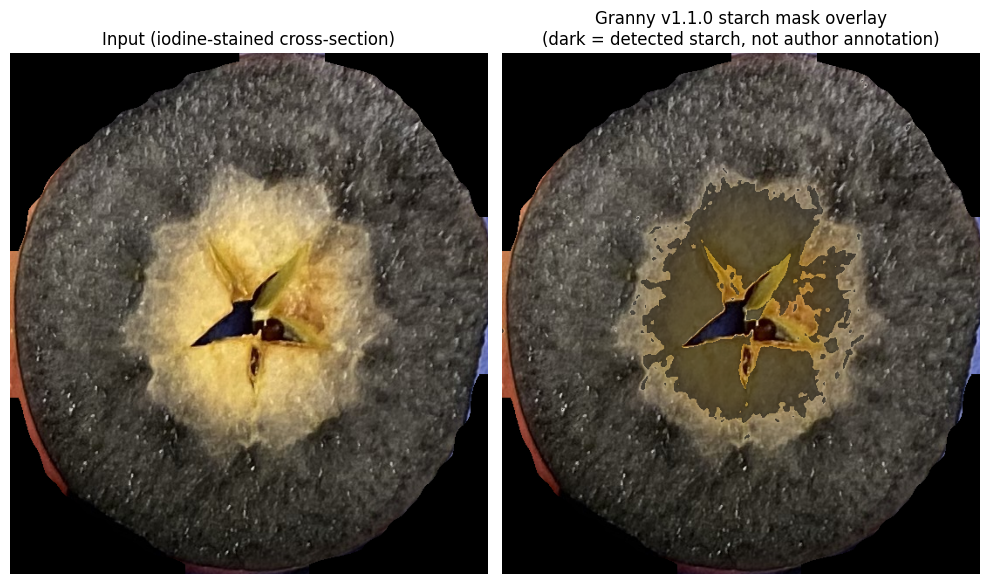

In [ ]:
example = "cross_section_demo_image_1.png"
img_in = cv2.cvtColor(cv2.imread(str(INPUT_DIR / example)), cv2.COLOR_BGR2RGB)
img_ov = cv2.cvtColor(cv2.imread(os.path.join(OUT_DIR, example)), cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(10, 6))
axes[0].imshow(img_in); axes[0].set_title("Input (iodine-stained cross-section)")
axes[1].imshow(img_ov)
axes[1].set_title("Granny v1.1.0 starch mask overlay\n(dark = detected starch, not author annotation)")
for ax in axes:
    ax.axis("off")
fig.tight_layout()
plt.show()

The same overlay for all 18 cross-sections, ordered by rating (most starch first) — an additional visualization created for this notebook.

**日本語:** 全18枚のオーバーレイをrating順（デンプンが多い順）に並べた追加の可視化です。

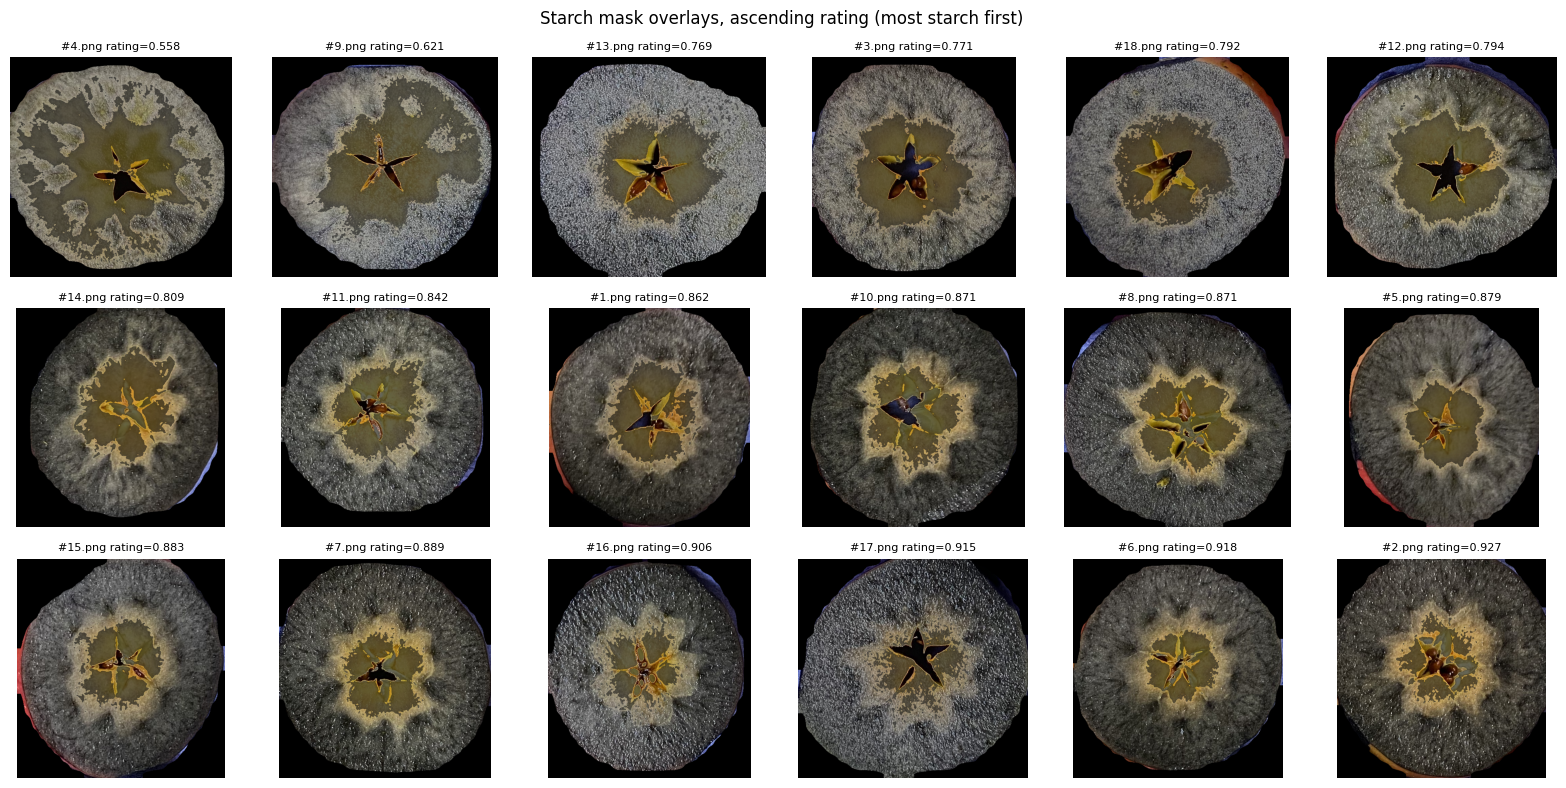

In [ ]:
order = df.sort_values("rating", ascending=True)["Name"].tolist()

fig, axes = plt.subplots(3, 6, figsize=(16, 8))
for ax, name in zip(axes.ravel(), order):
    ax.imshow(cv2.cvtColor(cv2.imread(os.path.join(OUT_DIR, name)), cv2.COLOR_BGR2RGB))
    r = float(df.loc[df["Name"] == name, "rating"].iloc[0])
    ax.set_title(f"{name.replace('cross_section_demo_image_', '#')} rating={r:.3f}", fontsize=8)
    ax.axis("off")
fig.suptitle("Starch mask overlays, ascending rating (most starch first)")
fig.tight_layout()
plt.show()

## 8. Cross-version comparison against the author's macro-era results

The author's `Results.csv` (ImageJ macro output for these same 18 images, shipped in the pinned commit) reports `Percent Starch Area` under the macro's own thresholds. The scatter compares it with the released module's `rating` (×100). This is an **implementation-to-implementation comparison on the same demo inputs** — the two use different thresholds/pipelines, so exact agreement is not expected.

**日本語:** 同じコミットに同梱されているImageJマクロの期待結果（`Percent Starch Area`）と、v1.1.0モジュールの rating×100 を散布図で比較します。閾値・処理が異なるため一致は求めず、「実装間比較」として見ます。

                       Name   rating  Percent Starch Area
 cross_section_demo_image_1 0.861608              93.5641
cross_section_demo_image_10 0.870632              90.5800
cross_section_demo_image_11 0.841590              85.3016
cross_section_demo_image_12 0.794240              80.9055
cross_section_demo_image_13 0.768902              72.7892
cross_section_demo_image_14 0.809142              90.3699
cross_section_demo_image_15 0.883205              92.7409
cross_section_demo_image_16 0.905651              90.1675
cross_section_demo_image_17 0.914860              93.2852
cross_section_demo_image_18 0.791922              94.1867
 cross_section_demo_image_2 0.926708              95.2143
 cross_section_demo_image_3 0.770626              84.6417
 cross_section_demo_image_4 0.558340              73.5738
 cross_section_demo_image_5 0.879282              92.6586
 cross_section_demo_image_6 0.917664              94.6469
 cross_section_demo_image_7 0.889453              91.5021
 cross_section

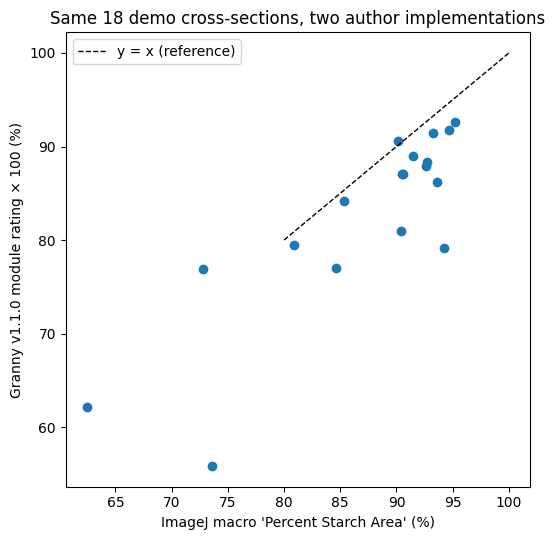

In [ ]:
macro = pd.read_csv(MACRO_RESULTS)
merged = df[["Name", "rating"]].copy()
merged["Name"] = merged["Name"].str.replace(r"\.png$", "", regex=True)
merged = merged.merge(macro[["Cross-Section", "Percent Starch Area"]],
                      left_on="Name", right_on="Cross-Section")
print(merged[["Name", "rating", "Percent Starch Area"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(merged["Percent Starch Area"], merged["rating"] * 100, c="tab:blue")
lims = [80, 100]
ax.plot(lims, lims, "k--", linewidth=1, label="y = x (reference)")
ax.set_xlabel("ImageJ macro 'Percent Starch Area' (%)")
ax.set_ylabel("Granny v1.1.0 module rating × 100 (%)")
ax.set_title("Same 18 demo cross-sections, two author implementations")
ax.legend()
fig.tight_layout()
plt.show()

## 9. Export results (within Colab)

A copy of the per-image table is saved to `/content/starch_rating_results.csv` for download via the Colab file browser.

**日本語:** 結果表を `/content/starch_rating_results.csv` に保存します（Colabのファイルブラウザからダウンロードできます）。

In [ ]:
export_path = "/content/starch_rating_results.csv"
df.to_csv(export_path, index=False)
print("saved:", export_path)
# from google.colab import files; files.download(export_path)  # uncomment to download

saved: /content/starch_rating_results.csv


## 10. Interpretation, limitations, references

**What was verified (this run, Colab CPU):** the pinned author release v1.1.0 (`411a6482`) processes the 18 author-provided demo cross-sections and produces per-image starch-area ratings and chart indices, masked overlay images, `results.csv` and `tray_summary.csv` (see the actual outputs above for this run's numbers).

**Limitations**
- This demonstrates **one module on one demo tray**; it is not a reproduction of the paper's dataset-level validation (the 36+36 starch-assessment images and human scores are not publicly available — Google Drive sign-in required).
- The preprint's implementation is an ImageJ macro; the current release reimplements the module in Python/OpenCV with different thresholding details. The macro-era `Results.csv` comparison above is cross-version context, not equivalence evidence.
- Detection/segmentation (Mask R-CNN / YOLO), scald, pear-color and blush modules, and the rater-bias analyses are out of scope. Chart index mappings are the author's calibration tables, unchanged.
- The PhenoPaper asset evidence recorded a content hash for an earlier revision of the demo image set (the numbering was reworked in Oct 2025); this notebook pins integrity against the current commit's git blob hashes instead.

**References**
- Preprint: bioRxiv 2024.04.03.588000v1, DOI 10.1101/2024.04.03.588000.
- Code: SystemsGenetics/granny, GPL-3.0, commit `411a64825292979f3539568832f9a9851cf854b0` (v1.1.0); macro history commit `b41f915e`.
- Docs: `docs/users_guide/modules/apples/starch_rating.rst`, `docs/users_guide/adjustable_parameters.rst`.

**日本語（限界）:** 本ノートブックは1トレー18枚のデモ画像に対する単一モジュールの動作確認です。論文のデータセット規模の検証（人手評価との比較）は未実施であり、前処版マクロと現行Python実装の差もあるため、比較は実装間の参考値です。